# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Sistem & Teknologi Multimedia  
**Nama:** Dina Rahma Dita  
**NIM:** 122140184

Referensi : https://chatgpt.com/share/691c649a-d788-8008-b391-64917f85428c  
Github : https://github.com/dinarahmadita06/kuliah-multimedia-25-26.git

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.


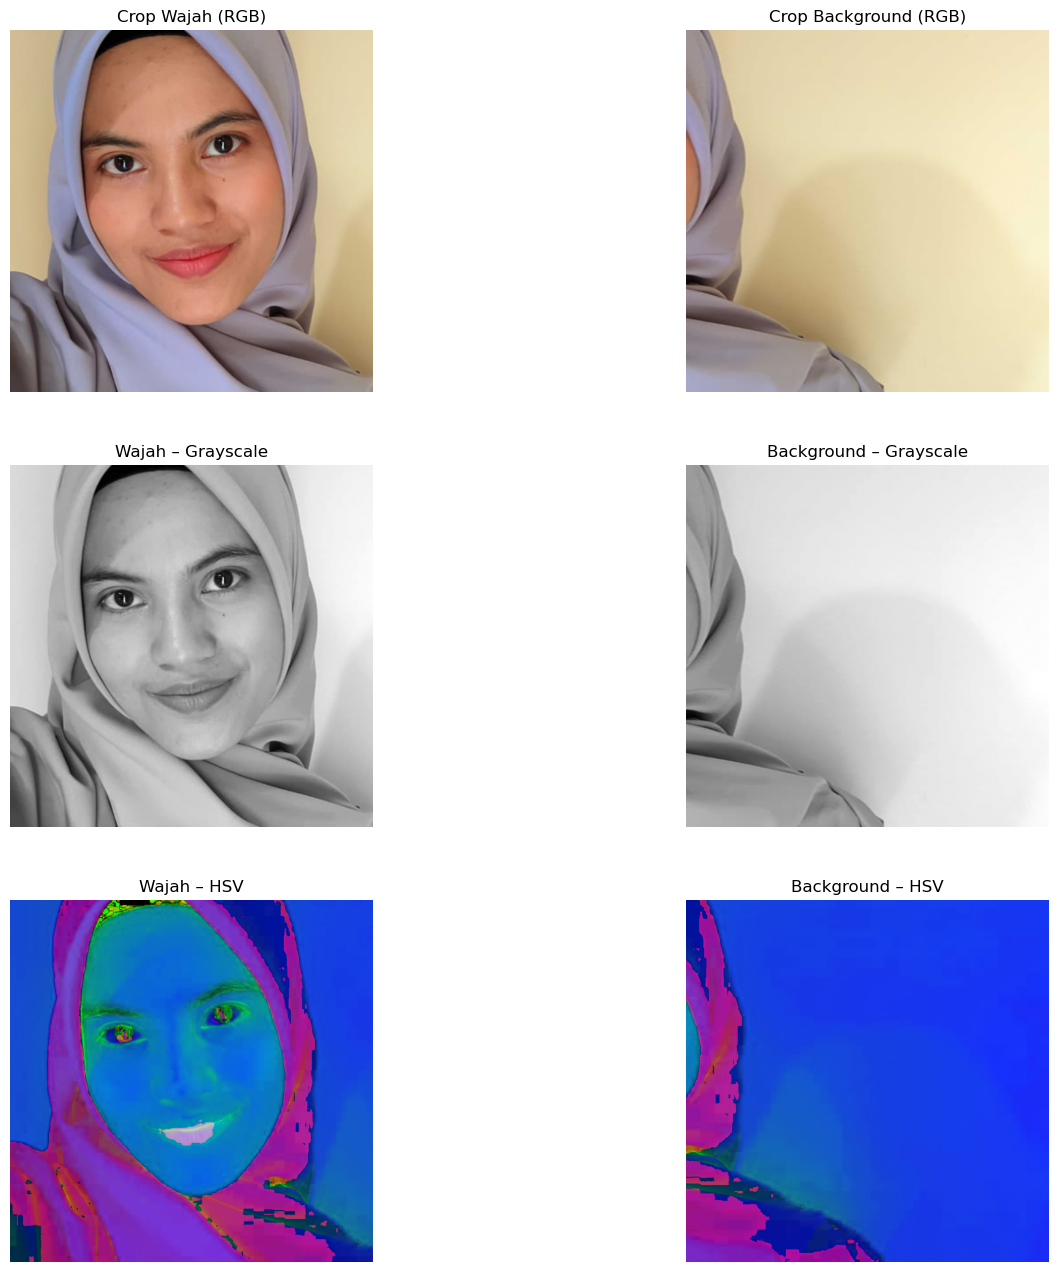

True

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar
img = cv2.imread("assets_ws4/1.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ----- 1. Crop Area Wajah (otomatis, area tengah foto) -----
h, w, _ = img.shape

# Koordinat crop wajah (dipilih berdasarkan posisi wajah pada foto)
# Area ini sudah disesuaikan agar mendapatkan crop persegi
face_x1 = int(w * 0.28)
face_y1 = int(h * 0.12)
face_x2 = int(w * 0.72)
face_y2 = face_y1 + (face_x2 - face_x1)  # buat persegi

crop_face = img[face_y1:face_y2, face_x1:face_x2]

# ----- 2. Crop Area Background (otomatis, sisi kanan foto) -----
bg_x1 = int(w * 0.60)
bg_y1 = int(h * 0.15)
bg_x2 = int(w * 0.92)
bg_y2 = int(h * 0.85)

crop_bg = img[bg_y1:bg_y2, bg_x1:bg_x2]

# ----- 3. Resize hasil crop menjadi 920×920 px -----
crop_face_resized = cv2.resize(crop_face, (920, 920))
crop_bg_resized = cv2.resize(crop_bg, (920, 920))

# ----- 4. Konversi ke Grayscale & HSV -----
face_gray = cv2.cvtColor(crop_face_resized, cv2.COLOR_RGB2GRAY)
face_hsv  = cv2.cvtColor(crop_face_resized, cv2.COLOR_RGB2HSV)

bg_gray = cv2.cvtColor(crop_bg_resized, cv2.COLOR_RGB2GRAY)
bg_hsv  = cv2.cvtColor(crop_bg_resized, cv2.COLOR_RGB2HSV)

# ----- 5. Tambahkan anotasi nama pada crop wajah -----
annotated_face = crop_face_resized.copy()
cv2.putText(
    annotated_face,
    "Dina Rahma Dita — 122140184",             
    (20, 60),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.8,
    (255, 255, 255),
    3
)

# ----- 6. Visualisasi hasil -----
plt.figure(figsize=(16, 16))

plt.subplot(3, 2, 1)
plt.imshow(crop_face_resized)
plt.title("Crop Wajah (RGB)")
plt.axis("off")

plt.subplot(3, 2, 2)
plt.imshow(crop_bg_resized)
plt.title("Crop Background (RGB)")
plt.axis("off")

plt.subplot(3, 2, 3)
plt.imshow(face_gray, cmap="gray")
plt.title("Wajah – Grayscale")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.imshow(bg_gray, cmap="gray")
plt.title("Background – Grayscale")
plt.axis("off")

plt.subplot(3, 2, 5)
plt.imshow(face_hsv)
plt.title("Wajah – HSV")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.imshow(bg_hsv)
plt.title("Background – HSV")
plt.axis("off")

plt.show()

# Hasil tambahan: simpan file jika perlu
cv2.imwrite("hasil_crop_wajah.png", cv2.cvtColor(crop_face_resized, cv2.COLOR_RGB2BGR))
cv2.imwrite("hasil_crop_background.png", cv2.cvtColor(crop_bg_resized, cv2.COLOR_RGB2BGR))


Cropping adalah proses memotong bagian tertentu dari gambar supaya kita hanya mengambil area yang penting, seperti wajah atau bagian background yang ingin dianalisis. Dengan memotong area yang tidak dibutuhkan, gambar menjadi lebih fokus dan lebih mudah diproses. Setelah dipotong, ukuran gambarnya dibuat sama, yaitu 920×920 piksel, agar semua gambar memiliki ukuran yang seragam. Ini penting karena ukuran yang konsisten membuat proses berikutnya—seperti perbandingan gambar atau analisis komputer—menjadi lebih rapi dan akurat.

Selain itu, gambar juga diubah warnanya agar lebih mudah diproses. Pada konversi grayscale, gambar diubah menjadi hitam-putih sehingga hanya tersisa satu nilai intensitas cahaya. Dengan cara ini, komputer jadi lebih mudah mendeteksi bentuk, bayangan, atau tepi objek tanpa terganggu oleh warna. Sementara itu, konversi ke HSV memisahkan warna menjadi tiga bagian: jenis warna (Hue), tingkat kejenuhan (Saturation), dan tingkat terang (Value). Format ini membantu ketika kita ingin memisahkan area tertentu berdasarkan warna, karena HSV lebih stabil terhadap perubahan cahaya dibandingkan RGB. Secara keseluruhan, kombinasi cropping dan perubahan warna membuat gambar lebih bersih, lebih fokus, dan lebih siap untuk diproses ke tahap berikutnya seperti thresholding, filtering, atau analisis lainnya.

### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


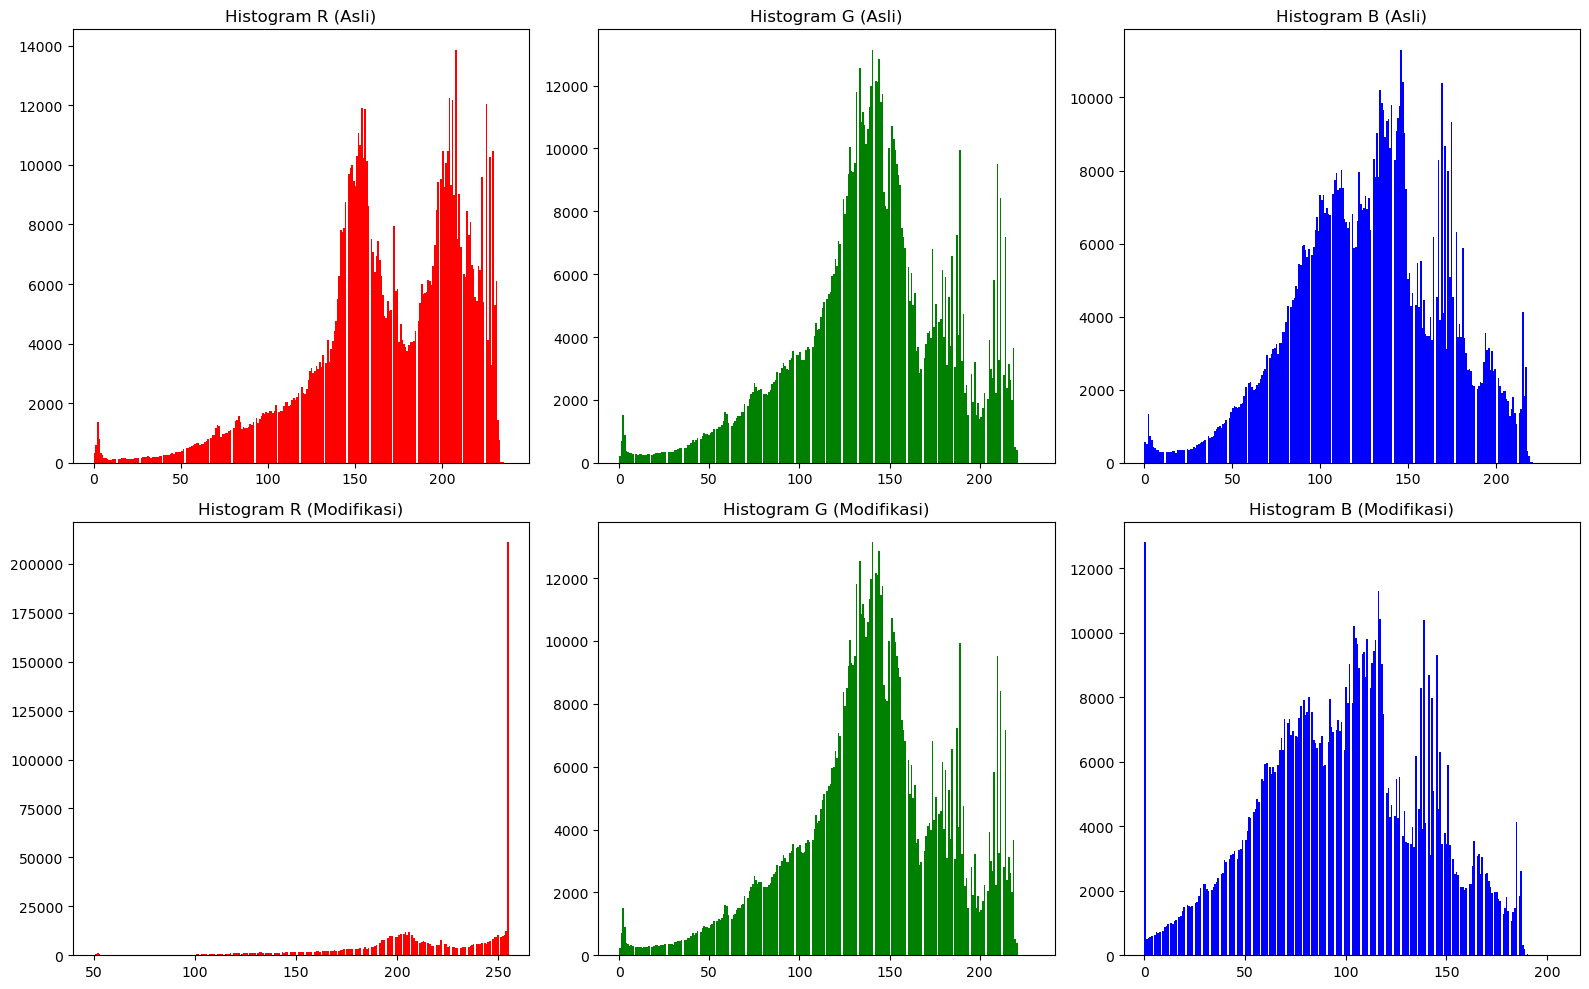

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Gunakan hasil crop wajah dari Soal 1
img = crop_face_resized.copy()   # pastikan variabel ini sudah ada

# Pastikan gambar dalam format RGB
img_rgb = img.copy().astype(np.int16)

# -------------------------------
# 1. Manipulasi Channel RGB
# -------------------------------
# Tambah intensitas merah +50 (maks 255)
img_rgb[:, :, 0] = np.clip(img_rgb[:, :, 0] + 50, 0, 255)

# Turunkan intensitas biru -30 (min 0)
img_rgb[:, :, 2] = np.clip(img_rgb[:, :, 2] - 30, 0, 255)

# Kembalikan ke tipe uint8
img_modified = img_rgb.astype(np.uint8)

# -------------------------------
# 2. Simpan sebagai PNG
# -------------------------------
cv2.imwrite("results_ws4/hasil_rgb_modifikasi.png", cv2.cvtColor(img_modified, cv2.COLOR_RGB2BGR))

# -------------------------------
# 3. Tampilkan histogram sebelum & sesudah
# -------------------------------
plt.figure(figsize=(16, 10))

# Gambar asli
plt.subplot(2, 3, 1)
plt.hist(img[:, :, 0].ravel(), bins=256, color="red")
plt.title("Histogram R (Asli)")

plt.subplot(2, 3, 2)
plt.hist(img[:, :, 1].ravel(), bins=256, color="green")
plt.title("Histogram G (Asli)")

plt.subplot(2, 3, 3)
plt.hist(img[:, :, 2].ravel(), bins=256, color="blue")
plt.title("Histogram B (Asli)")

# Gambar hasil modifikasi
plt.subplot(2, 3, 4)
plt.hist(img_modified[:, :, 0].ravel(), bins=256, color="red")
plt.title("Histogram R (Modifikasi)")

plt.subplot(2, 3, 5)
plt.hist(img_modified[:, :, 1].ravel(), bins=256, color="green")
plt.title("Histogram G (Modifikasi)")

plt.subplot(2, 3, 6)
plt.hist(img_modified[:, :, 2].ravel(), bins=256, color="blue")
plt.title("Histogram B (Modifikasi)")

plt.tight_layout()
plt.show()


Modifikasi Kanal Merah (+50)
Menambah nilai pada kanal merah sebesar 50 membuat gambar tampak lebih hangat. Warna merah menjadi lebih kuat, sehingga bagian kulit terlihat lebih kemerahan. Secara keseluruhan, gambar berubah ke arah warna merah-oranye, sehingga tampilannya terasa lebih hangat dibanding sebelumnya.


Modifikasi Kanal Biru (–30)
Mengurangi nilai pada kanal biru sebesar 30 membuat warna biru pada gambar menjadi lebih lemah. Bagian yang sebelumnya tampak kebiruan akan terlihat lebih gelap dan kusam. Dampaknya, gambar terlihat kurang “dingin” dan semakin condong ke warna hangat.


Perubahan pada Histogram Channel
- Histogram R (merah) bergeser ke kanan karena intensitas warna merah meningkat.
- Histogram B (biru) bergeser ke kiri karena intensitas warna biru berkurang.
- Histogram G (hijau) hampir tidak berubah karena kanal ini tidak dimodifikasi.

Secara keseluruhan, perubahan nilai kanal RGB ini membuat warna gambar berubah menjadi lebih hangat dan kemerahan. 

Berikut ini adalah penjelasan dari perubahan histogram pada masing-masing channel:
1. Channel Merah (R)
Histogram Asli
- Nilai merah tersebar dari sekitar 0 sampai 230.
- Ada dua puncak di intensitas 150–200, yang biasanya berasal dari warna kulit dan bagian terang pada gambar.
Histogram Setelah Modifikasi
- Semua nilai merah bergeser ke kanan karena ditambah 50 poin.
- Banyak nilai yang “menabrak” batas 255 sehingga berubah menjadi 255 (clipping).
- Akibatnya, muncul puncak besar (spike) di bagian paling kanan histogram. \
Gambar terlihat lebih merah dan terasa lebih hangat karena warna merah diperkuat dan banyak bagian mencapai intensitas maksimum.

2. Channel Hijau (G)
Histogram Asli
- Nilai hijau menyebar dari sekitar 0 sampai 220.
- Puncak tertinggi ada di intensitas 130–170, sesuai dengan warna wajah dan background.
Histogram Setelah Modifikasi
- Bentuk histogram hampir tidak berubah sama sekali.\
Karena kanal hijau tidak diubah, tampilan warna hijau pada gambar tetap sama seperti sebelumnya.

3. Channel Biru (B)
Histogram Asli
- Nilai biru tersebar dari 0 sampai 220.
- Ada puncak di area 100–170, berasal dari warna kulit dan objek yang mengandung biru.
Histogram Setelah Modifikasi
- Histogram bergeser ke kiri karena nilai biru dikurangi 30 poin.
- Banyak nilai menjadi sangat rendah (0–30), membuat puncak tinggi di bagian kiri histogram.\
Warna biru melemah sehingga gambar tampak lebih kekuningan/keemasan. Ini terjadi karena warna biru yang memberi kesan “dingin” dikurangi intensitasnya.

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


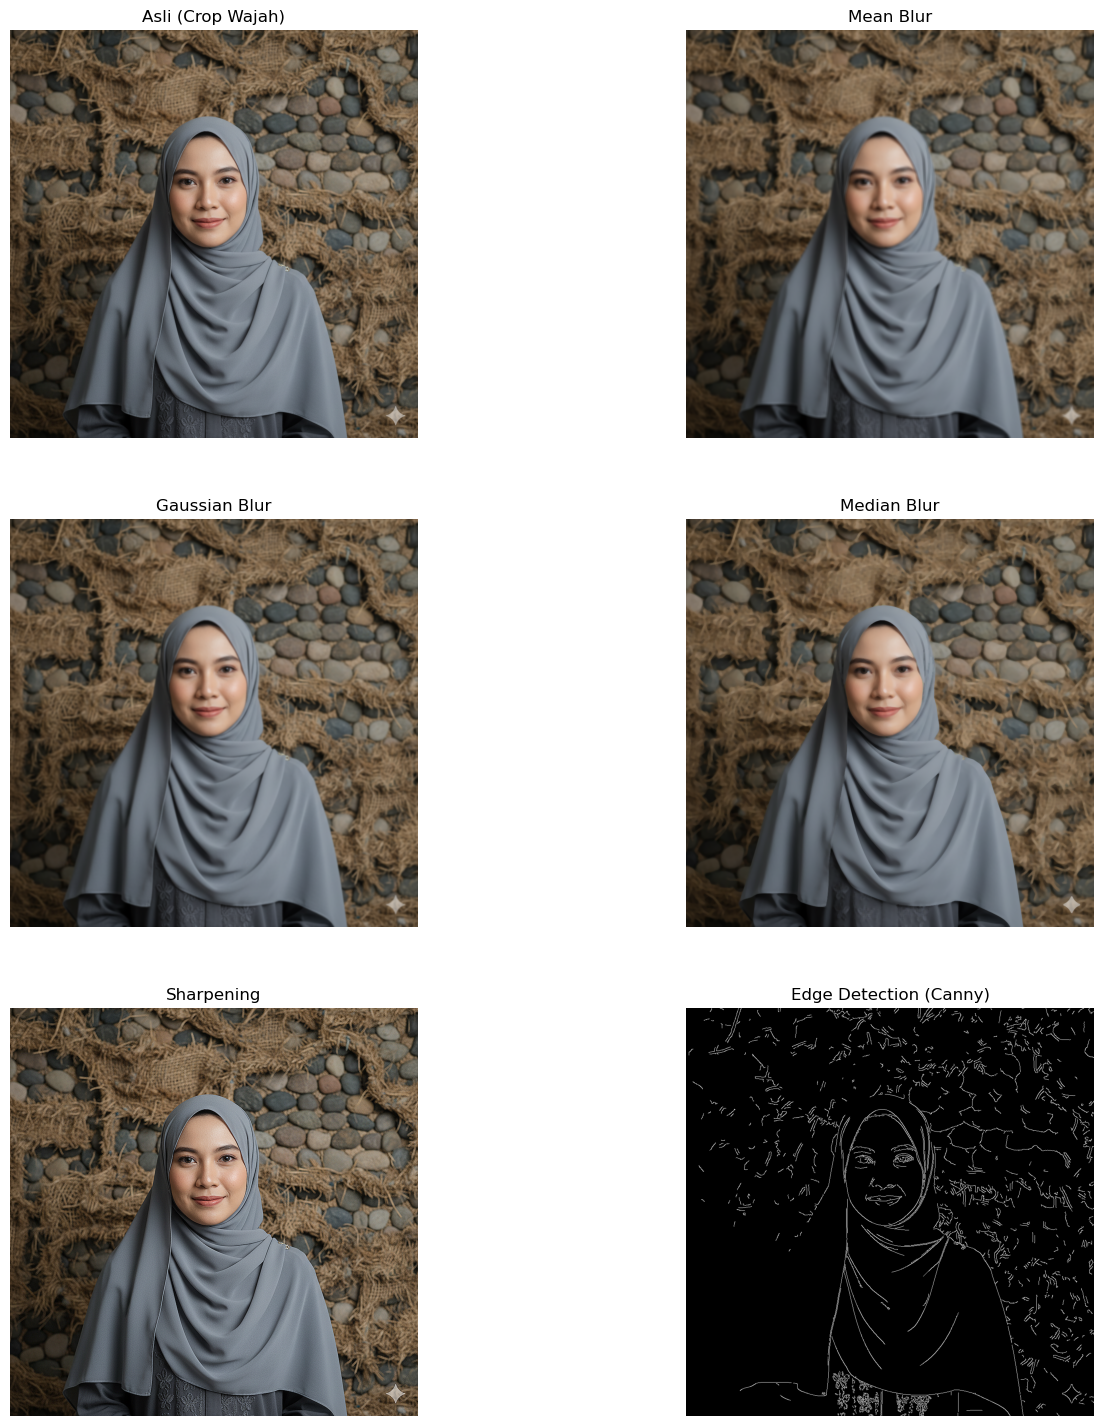

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("assets_ws4/3.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# -----------------------------------
# 1. MEAN / AVERAGING FILTER
# -----------------------------------
mean_blur = cv2.blur(img, (7, 7))

# -----------------------------------
# 2. GAUSSIAN BLUR
# -----------------------------------
gaussian_blur = cv2.GaussianBlur(img, (7, 7), 0)

# -----------------------------------
# 3. MEDIAN FILTER
# -----------------------------------
median_blur = cv2.medianBlur(img, 7)

# -----------------------------------
# 4. SHARPENING (CUSTOM KERNEL)
# -----------------------------------
kernel_sharp = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])
sharpen = cv2.filter2D(img, -1, kernel_sharp)

# -----------------------------------
# 5. EDGE DETECTION (CANNY)
# -----------------------------------
edge = cv2.Canny(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), 100, 180)

# -----------------------------------
# VISUALISASI
# -----------------------------------
plt.figure(figsize=(16, 18))

titles = [
    "Asli (Crop Wajah)",
    "Mean Blur",
    "Gaussian Blur",
    "Median Blur",
    "Sharpening",
    "Edge Detection (Canny)"
]

images = [img, mean_blur, gaussian_blur, median_blur, sharpen, edge]

for i, (im, title) in enumerate(zip(images, titles)):
    plt.subplot(3, 2, i + 1)
    if title == "Edge Detection (Canny)":
        plt.imshow(im, cmap="gray")
    else:
        plt.imshow(im)
    plt.title(title)
    plt.axis("off")

plt.show()


Penjelasan setiap filter: 

1. Mean Blur (Averaging) \
Filter ini bekerja dengan merata-ratakan nilai piksel di area sekitar (misalnya kotak 7×7).
Efeknya:
- Detail halus di wajah dan background jadi lebih lembut.
- Tekstur dinding dan kain jadi kurang tajam.
- Hasil blur terlihat sedikit kasar karena hanya merata-ratakan piksel.
2. Gaussian Blur \
Filter ini menggunakan perhitungan yang lebih halus, di mana piksel bagian tengah lebih berpengaruh.
Efeknya:
- Blur tampak lebih natural dan lembut.
- Mengurangi noise kecil dan detail yang terlalu tajam.
- Wajah tetap terlihat jelas tanpa kehilangan banyak detail.
- Lebih rapi dibanding mean blur.
3. Median Blur \
Filter ini mengganti nilai piksel dengan nilai median dari area sekitar.
Efeknya:
- Bagus untuk menghilangkan noise seperti bintik hitam/putih.
- Wajah jadi lebih halus tapi bentuk tepi tetap jelas.
- Tekstur background masih terlihat, hanya lebih rapi.
- Tidak sehalus Gaussian, tapi lebih baik dalam menjaga tepi.
4. Sharpening \
Filter ini mempertegas perbedaan antara piksel tengah dan sekitarnya.
Efeknya:
- Detail wajah jadi lebih tajam.
- Tekstur background terlihat lebih jelas dan kontras.
- Garis-garis halus tampak lebih tegas.
- Kalau berlebihan bisa membuat gambar terlalu tajam, tapi di sini hasilnya membuat wajah lebih detail.
5. Edge Detection (Canny) \
Filter ini mencari tepi berdasarkan perubahan intensitas pada gambar.
Efeknya:
- Hasil berupa garis putih di atas latar hitam.
- Kontur wajah, hijab, dan tubuh terlihat jelas.
- Background yang bertekstur menghasilkan banyak garis tipis.
- Tidak menampilkan warna, hanya bentuk tepi objek.



### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

In [2]:
import cv2
import mediapipe as mp

# ---------------------------
# LOAD GAMBAR
# ---------------------------
img = cv2.imread("assets_ws4/3.png")
if img is None:
    raise FileNotFoundError("Gambar 3.png tidak ditemukan!")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape

# ---------------------------
# MEDIAPIPE FACE MESH
# ---------------------------
mp_face = mp.solutions.face_mesh
face_mesh = mp_face.FaceMesh(static_image_mode=True, refine_landmarks=True)

result = face_mesh.process(img_rgb)

if not result.multi_face_landmarks:
    print("Wajah tidak terdeteksi!")
    exit()

landmarks = result.multi_face_landmarks[0].landmark

# ---------------------------
# LANDMARK UNTUK MAHKOTA
# ---------------------------
left_face  = landmarks[234]   # sisi kiri wajah
right_face = landmarks[454]   # sisi kanan wajah
forehead   = landmarks[10]    # dahi

# Konversi ke pixel
lx, ly = int(left_face.x * w), int(left_face.y * h)
rx, ry = int(right_face.x * w), int(right_face.y * h)
fx, fy = int(forehead.x * w), int(forehead.y * h)

# ---------------------------
# HITUNG POSISI DAN UKURAN MAHKOTA
# ---------------------------
filter_width = int((rx - lx) * 1.4)       # lebih lebar dari wajah
filter_height = int(filter_width * 0.6)   # tinggi proporsional

# Diletakkan lebih ke atas dari dahi
x1 = fx - filter_width // 2
y1 = fy - filter_height

# ---------------------------
# LOAD FILE MAHKOTA (PNG)
# ---------------------------
crown = cv2.imread("assets_ws4/crown.png", cv2.IMREAD_UNCHANGED)
if crown is None:
    raise FileNotFoundError("crown.png tidak ditemukan!")

crown = cv2.resize(crown, (filter_width, filter_height))

# ---------------------------
# ALPHA BLENDING (Overlay)
# ---------------------------
overlay = img.copy()

for i in range(filter_height):
    for j in range(filter_width):
        if 0 <= y1 + i < h and 0 <= x1 + j < w:
            alpha = crown[i, j, 3] / 255.0
            for c in range(3):
                overlay[y1 + i, x1 + j, c] = (
                    alpha * crown[i, j, c] +
                    (1 - alpha) * overlay[y1 + i, x1 + j, c]
                )

# ---------------------------
# CLOSE MEDIAPIPE
# ---------------------------
face_mesh.close()

# ---------------------------
# TAMPILKAN HASIL
# ---------------------------
cv2.imshow("Asli", img)
cv2.imshow("Filter Mahkota", overlay)
cv2.waitKey(0)
cv2.destroyAllWindows()


Gambar Asli \
Pada gambar asli, wajah terlihat apa adanya tanpa tambahan apa pun. Semua bagian seperti wajah, hijab, dan background masih dalam kondisi normal.

Gambar dengan Filter Mahkota \
Pada gambar hasil, sebuah mahkota digital muncul di atas kepala. Posisi mahkota ini dihitung berdasarkan landmark wajah yang dideteksi menggunakan MediaPipe. Dengan cara ini, mahkota dapat menyesuaikan ukuran dan posisi kepala sehingga terlihat pas.
Efek transparansi dari PNG dan alpha blending juga membantu membuat mahkota tampak menyatu dengan gambar.

Cara Menghitung Overlay Mahkota : \
Untuk menempatkan mahkota di kepala, saya menggunakan tiga titik (landmark) dari MediaPipe: 
- titik kiri wajah (234) 
- titik kanan wajah (454) 
- titik dahi (10) 

Dari landmark kiri dan kanan, dihitung lebar wajah, lalu membuat lebar mahkota sedikit lebih besar dari itu supaya terlihat pas:
lebar_mahkota = (kanan - kiri) × 1.4 \
tinggi_mahkota = lebar_mahkota × 0.6 \
Untuk posisi, saya menggunakan titik dahi sebagai acuan, lalu meletakkan mahkota di atas titik tersebut: \
x = titik_dahi_x - setengah_lebar_mahkota \
y = titik_dahi_y - tinggi_mahkota \
Dengan cara ini, mahkota selalu jatuh di posisi yang benar dan ukurannya menyesuaikan bentuk wajah.



### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

In [1]:
import cv2
import numpy as np

# ---------------------------
# 1. Load gambar
# ---------------------------
img = cv2.imread("assets_ws4/5.png")
orig = img.copy()

# ---------------------------
# 2. Grayscale
# ---------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ---------------------------
# 3. Koreksi Perspektif
# ---------------------------
pts_src = np.float32([
    [0, 3],        # kiri atas
    [1015, 5],     # kanan atas
    [1020, 713],   # kanan bawah
    [4, 713]       # kiri bawah
])

# Tentukan ukuran output (proporsional)
width_final = 1000
height_final = 1400

pts_dst = np.float32([
    [0, 0],
    [width_final, 0],
    [width_final, height_final],
    [0, height_final]
])

# Hitung homografi dan warp
H = cv2.getPerspectiveTransform(pts_src, pts_dst)
warp = cv2.warpPerspective(img, H, (width_final, height_final))

# ---------------------------
# 4. Thresholding (Otsu)
# ---------------------------
warp_gray = cv2.cvtColor(warp, cv2.COLOR_BGR2GRAY)
_, thresh_otsu = cv2.threshold(warp_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ---------------------------
# 5. Susun hasil dalam grid
# ---------------------------
def resize_fixed(img, width=350, height=500):
    return cv2.resize(img, (width, height))

gray_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
warp_bgr = resize_fixed(warp)
thresh_bgr = cv2.cvtColor(thresh_otsu, cv2.COLOR_GRAY2BGR)

grid1 = np.hstack([
    resize_fixed(orig),
    resize_fixed(gray_bgr),
    warp_bgr,
    resize_fixed(thresh_bgr)
])

# ---------------------------
# 6. Tampilkan hasil
# ---------------------------
cv2.imshow("Tahapan Pemrosesan (Asli - Grayscale - Warp - Threshold)", grid1)
cv2.waitKey(0)
cv2.destroyAllWindows()


Penjelasan Soal 5 :

1. Grayscale \
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) \
Fungsi tahap ini:
- Mengubah gambar berwarna menjadi abu-abu.
- Mengurangi informasi yang tidak perlu.
- Membuat kontras lebih terlihat.
Manfaat: \
Grayscale membuat tahap berikutnya seperti homografi dan thresholding bekerja lebih stabil.

2. Koreksi Perspektif (Homografi) \
Empat titik sudut kertas dipilih secara manual: \
pts_src = np.float32([ 
    [0, 3], [1015, 5], [1020, 713], [4, 713]
]) \
Tujuan: 
- Meluruskan kertas yang difoto miring.
- Mengubah bentuk trapezoid menjadi persegi panjang.
Transformasi: \
H = cv2.getPerspectiveTransform(pts_src, pts_dst) \
warp = cv2.warpPerspective(img, H, (width_final, height_final)) \
Manfaat: \
Kertas menjadi tampak rata dan rapi seperti hasil scan.

3. Thresholding (Otsu) \
_, thresh_otsu = cv2.threshold(warp_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) \
Fungsi:
- Mengubah gambar menjadi hitam-putih.
- Otsu otomatis memilih nilai threshold terbaik.
Alasan memilih Otsu:
- Cocok untuk dokumen dengan pencahayaan tidak merata.
- Tidak perlu menentukan angka threshold manual.
- Membuat tulisan lebih jelas dan kontras.

4. Grid Perbandingan \
Semua tahapan disusun dalam satu baris: \
grid1 = np.hstack([orig, gray_bgr, warp_bgr, thresh_bgr]) \
Tujuan: \
Memudahkan melihat perubahan dari gambar asli → grayscale → diluruskan → hitam-putih.



### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.